#### <span style="color:cyan">**Imports**</span>

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from util.data_preprocessing import *
from util.pca_plotting import *
from util.classes.PCADataset import *
from util.classes.PcaMLP import *
from util.model_eval import *
from util.model_optimization import *

from preprocessing.pipelines import build_pca_pipeline
import json
import os
import math
import numpy as np
import torch

#### <span style="color:cyan">**Data Preprocessing**</span>


geometry labels (8D):
['tlw' 'blw' 'h' 's' 'width_sum' 'width_diff' 'aspect_ratio' 'fill_factor']

geometry_table (8D):
             tlw     blw       h       s  width_sum  width_diff  aspect_ratio  \
run_id                                                                          
run_0001  1.2669  4.7719  0.3148  2.2044     6.0388     -3.5050      0.142805   
run_0002  0.8049  4.2139  0.4596  3.9027     5.0188     -3.4090      0.117765   
run_0003  0.3041  3.1507  0.2406  3.3466     3.4548     -2.8466      0.071894   
run_0004  2.3454  4.7269  0.6228  4.2708     7.0723     -2.3815      0.145827   
run_0005  0.9830  3.6620  0.4859  4.9945     4.6450     -2.6790      0.097287   

          fill_factor  
run_id                 
run_0001     1.369715  
run_0002     0.642991  
run_0003     0.516166  
run_0004     0.827983  
run_0005     0.465012  

Feature table (abs):
              pc_0      pc_1      pc_2      pc_3      pc_4      pc_5  \
run_id                                           

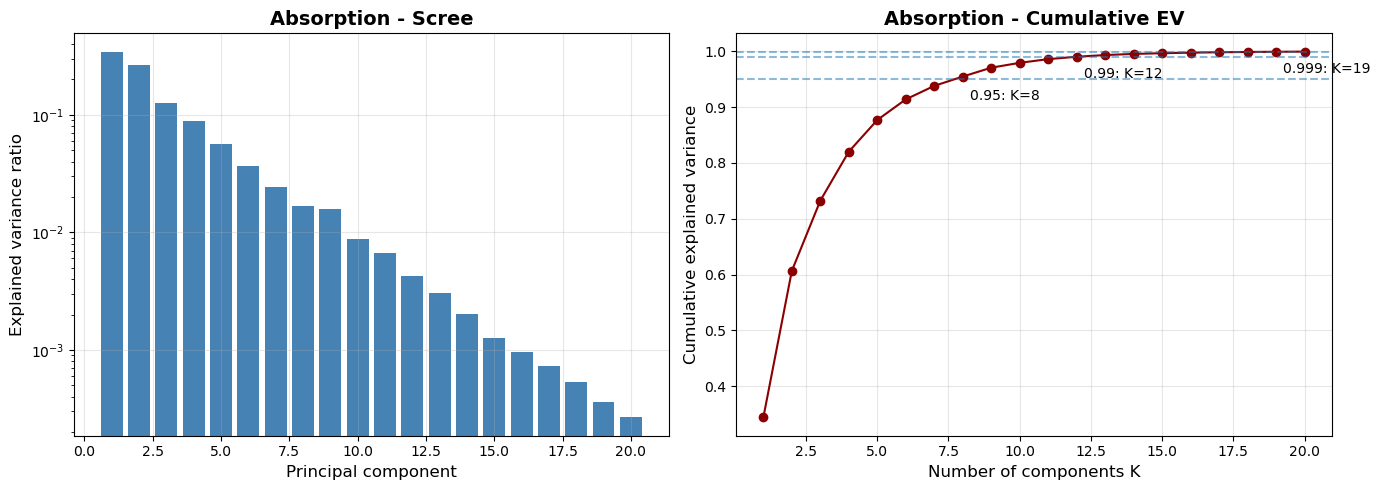

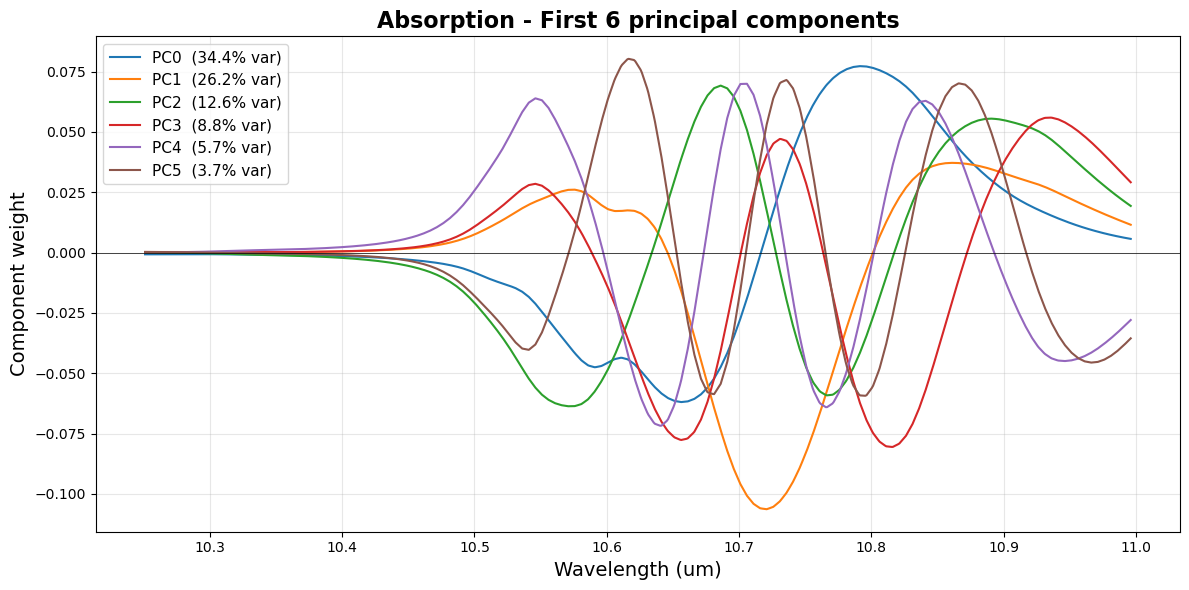

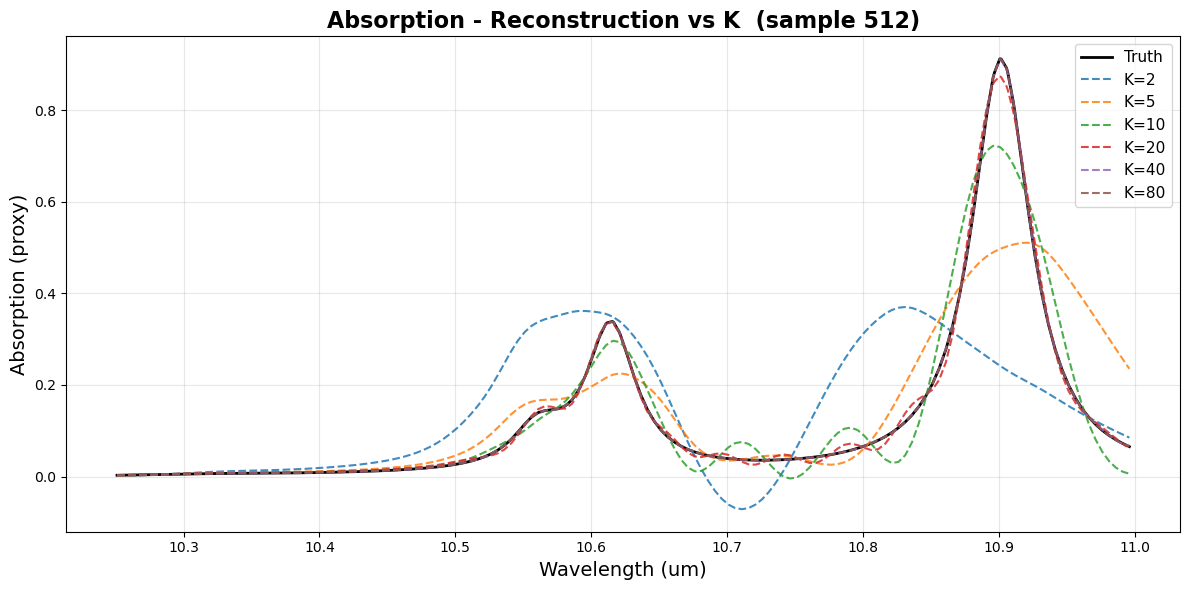

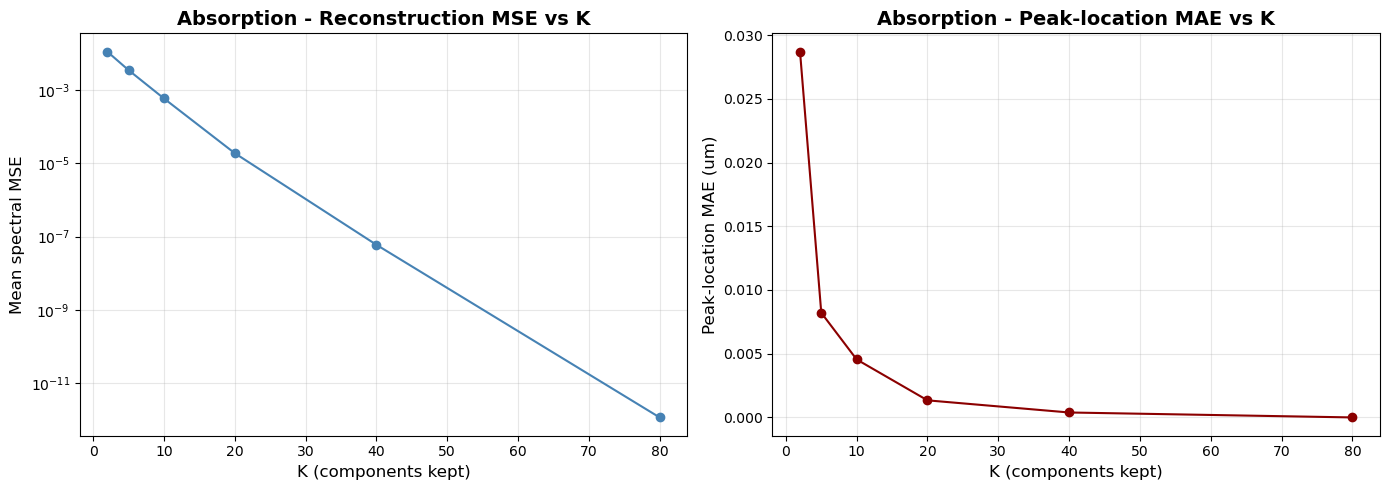

Absorption K-sweep:
  K=  2  MSE=1.123e-02  peak-MAE=0.0287 um
  K=  5  MSE=3.515e-03  peak-MAE=0.0082 um
  K= 10  MSE=5.921e-04  peak-MAE=0.0045 um
  K= 20  MSE=1.898e-05  peak-MAE=0.0013 um
  K= 40  MSE=5.999e-08  peak-MAE=0.0004 um
  K= 80  MSE=1.160e-12  peak-MAE=0.0000 um


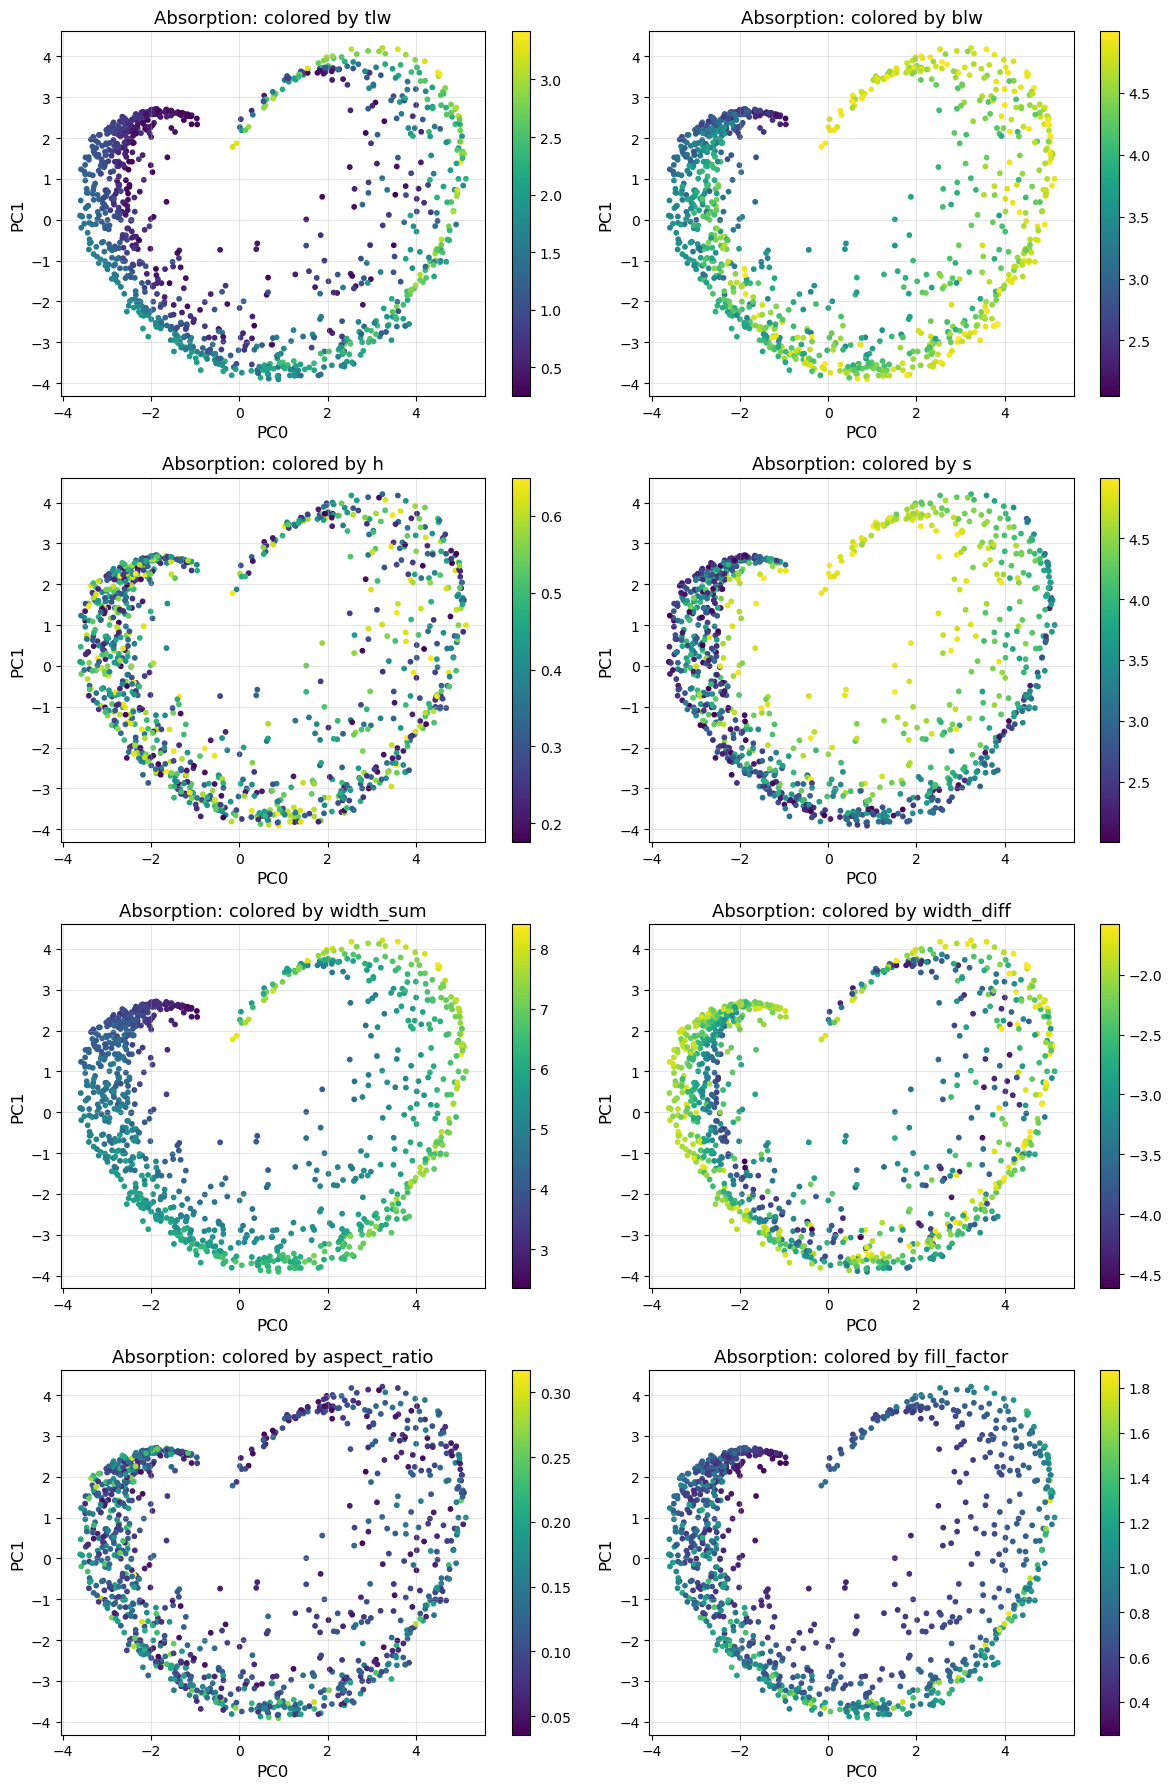

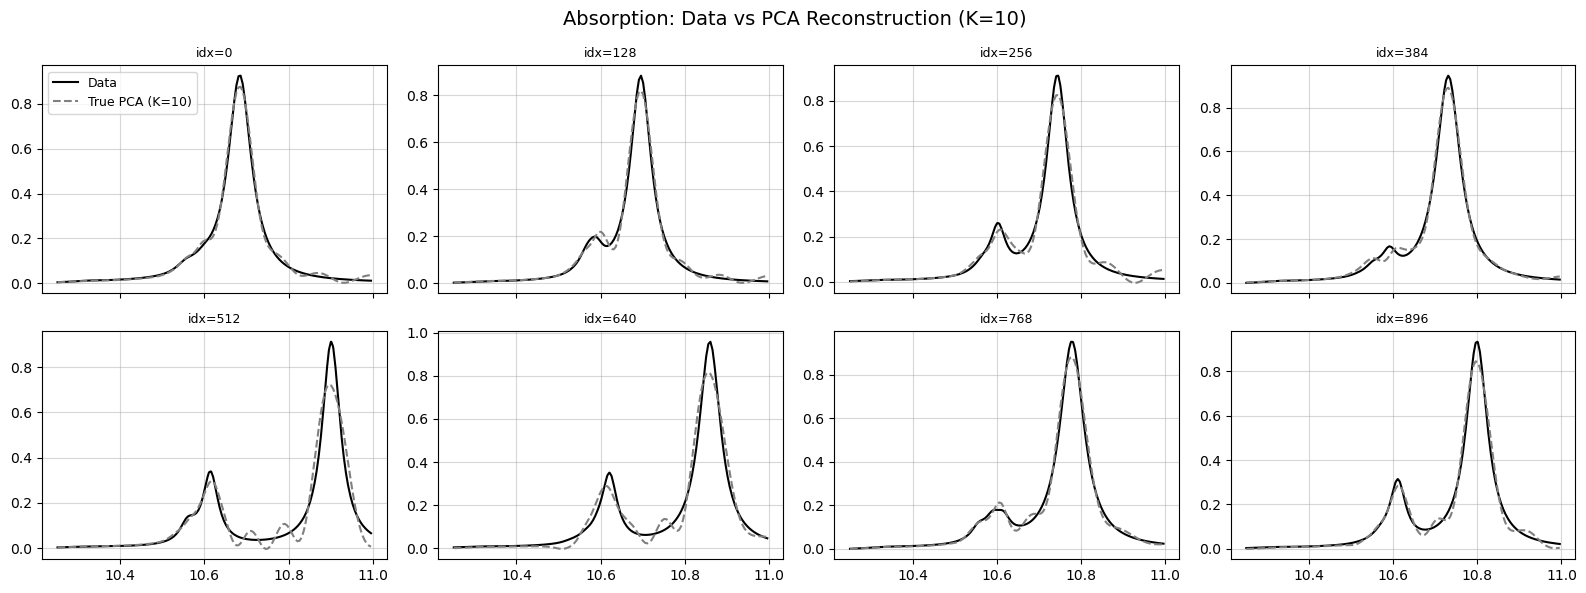

In [8]:
#### DATA PREPROCESSING PIPELINE - PCA FEATURES (8D GEOMETRY) ####
# Config
pd.set_option('display.max_columns', 10)
DATA_PATH = '../data/batch2'
DOMAIN = (10.25, 11.0)
TEST_IDX = np.arange(0, 1024, 128)
INTERP = 4
K = 10
K_SWEEP = [2, 5, 10, 20, 40, 80]
N_PC_SHOW = 6

# Import Data
geom_labels, geom_table, refl_data, abs_data, refl_bg, abs_bg, wl = import_data(DATA_PATH)

# Augment geometry table from 4D -> 8D
geom_table_8d = derive_geometry_features(geom_table)
geom_labels_8d = geom_table_8d.columns.to_numpy()

# Print Data and geometry Table for inspection
print(f'\ngeometry labels (8D):\n{geom_labels_8d}\n')
print(f'geometry_table (8D):\n{geom_table_8d.head()}\n')
# print(f'absorption data:\n{abs_data.head()}\n')
# print(f'absorption background:\n{abs_bg.head()}\n')

# Build and fit preprocessing pipelines
abs_pipe  = build_pca_pipeline(K, DOMAIN, INTERP, background=abs_bg)
abs_ft_pca  = abs_pipe.fit_transform(abs_data)
abs_pca  = abs_pipe.named_steps['pca'].artifacts_

# Processed spectra (all steps except PCA) — used by exploration plots below
abs_data  = abs_pipe[:-1].fit_transform(abs_data)
wl = abs_data.columns.to_numpy(dtype=float)

# Print feature table for inspection
print(f'Feature table (abs):\n{abs_ft_pca.head()}\n')


#### EXPLORATION PLOTS ####
# 1) Scree / cumulative explained variance
plot_scree(abs_pca, 'Absorption', k_max=20)

# 2) Shapes of the first N principal components
plot_pc_shapes(abs_pca, 'Absorption', N_PC_SHOW)

# 3) Reconstruction fidelity vs K on a single example spectrum
demo_idx = int(TEST_IDX[len(TEST_IDX) // 2])
plot_k_sweep_reconstruction(abs_data, abs_pca, demo_idx, K_SWEEP, 'Absorption')

# 4) Spectral MSE and peak-location MAE vs K (dataset-wide diagnostic)
plot_k_sweep_error(abs_data, abs_pca, K_SWEEP, 'Absorption')

# 5) Latent space scatter: PC0 vs PC1 colored by each geometry parameter (all 8).
plot_latent_colored_by_geom(abs_ft_pca, geom_table_8d, geom_labels_8d, 'Absorption')

# 6) Reconstruction grid: data (target) vs K-component PCA reconstruction
#    for each sample in TEST_IDX. Direct visual check of PCA fidelity.
plot_reconstruction_grid(abs_data, abs_pca, TEST_IDX, 'Absorption')


#### DATA EXPORT ####
# Create export dict (same format as pca_4D.py; geometry_table is now 8D)
pca_ft = {
    "wl": wl,
    "absorption": abs_data,
    "absorption_features": abs_ft_pca,
    "absorption_pca": abs_pca,
    "geometry_labels": geom_labels_8d,
    "geometry_table": geom_table_8d,
    "K": K,
}

data_config = {
    "data_path": DATA_PATH,
    "domain": DOMAIN,
    "interpolation_density": INTERP,
    "K": K,
    "geometry_dim": 8,
    "derived_features": ["width_sum", "width_diff", "aspect_ratio", "fill_factor"],
}


#### <span style="color:cyan">**Training - Configuration**</span>

In [10]:
ROOT = "trained_models/pca_8D"
NAME = "optimization1_pruning"
DIR = f'{ROOT}/{NAME}'
os.makedirs(f'{DIR}', exist_ok=True)
os.makedirs(f'{DIR}/config', exist_ok=True)
os.makedirs(f'{DIR}/models', exist_ok=True)
os.makedirs(f'{DIR}/results', exist_ok=True)

#### CONFIG ####
# Note that the data and data config comes from the chose preprocessing file
TEST_IDX = np.arange(0, 1024, 50)
loader_config = {
    "seed": 1234,
    "test_ratio": 0.15,
    "splits": 4,
    "pre_split": {},
    "shuffle": True,
    "batch_size": 64
}
MLP_config = {
    "hidden_dim": 384,
    "n_layers": 4,
    "k": 10,
    "p": 0.00,
    'input_dim': 8
}
train_config = {
    "epochs": 500,
    "lr": 8.77e-3,
    "wd": 4.01e-5,
    "patience": 100,
    "path": f'{DIR}/models'
}

#### SETUP OBJECTS ####
data = PCADataset(
    pca_ft['geometry_table'],
    pca_ft['absorption_features'],
    pca_ft['absorption_pca'],
    normalize_geom = True,
    normalize_feat = False
)

# Raw absorption spectra aligned with dataset order (used for 3-curve plots)
_sorted_ids = pca_ft['geometry_table'].sort_index().index
_raw_abs = pca_ft['absorption'].loc[_sorted_ids].to_numpy()

kf_indices, test_indices = generate_kfold(
    data,
    loader_config['splits'],
    loader_config['seed'],
    loader_config['test_ratio']
)
train_config['test_indices'] = test_indices

#### <span style="color:cyan">**Training - CV**</span>

In [11]:
model = PcaMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    input_dim = MLP_config["input_dim"]
)

#### TRAINING LOOP ####
fold_metrics = {
    "best_val_coeff_mse": [],
    "best_val_recon_mse": [],
    "best_val_recon_rmse": [],
    "peak_mae": [],
    "peak_loc_error_um": [],
    "train_val_gap_coeff": [],
    "train_val_gap_recon": [],
    "best_epoch": [],
    "epochs_trained": [],
}

wl_tensor = torch.tensor(np.asarray(data.wl), dtype=torch.float32)

for i, (train_idx, val_idx) in enumerate(kf_indices):
    os.makedirs(f'{train_config["path"]}/fold{i}', exist_ok=True)

    model = PcaMLP(
        MLP_config['k'],
        MLP_config["hidden_dim"],
        MLP_config["n_layers"],
        MLP_config['p'],
        input_dim=MLP_config["input_dim"]
    )

    train_loader, val_loader = create_dataloader_kfold(
        data,
        loader_config['seed'],
        train_idx,
        val_idx,
        loader_config['batch_size']
    )

    model_state, history = train_pca_regression(
        model,
        data,
        train_loader,
        val_loader,
        train_config["epochs"],
        train_config['lr'],
        train_config["wd"],
        train_config["patience"],
        f'{train_config["path"]}/fold{i}'
    )

    # Per-fold scalar metrics. train_pca_regression reloads the best checkpoint
    # before returning, so `model` is the best-val-epoch weights.
    best_ep = history["stop_epoch"]
    best_val_coeff = history["val_loss"][best_ep]
    best_val_recon = history["val_loss_recon"][best_ep]
    best_train_coeff = history["train_loss"][best_ep]
    best_train_recon = history["train_loss_recon"][best_ep]

    # Peak metrics on the val set with the loaded best model.
    model.eval()
    peak_abs_errs = []
    peak_loc_errs = []
    with torch.no_grad():
        for geom, feat in val_loader:
            pred_spec = data.reconstruct_spectrum(model(geom))
            true_spec = data.reconstruct_spectrum(feat)
            pred_peak = pred_spec.max(dim=-1)
            true_peak = true_spec.max(dim=-1)
            peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
            peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())
    peak_mae = torch.cat(peak_abs_errs).mean().item()
    peak_loc_err = torch.cat(peak_loc_errs).mean().item()

    fold_metrics["best_val_coeff_mse"].append(float(best_val_coeff))
    fold_metrics["best_val_recon_mse"].append(float(best_val_recon))
    fold_metrics["best_val_recon_rmse"].append(float(math.sqrt(best_val_recon)))
    fold_metrics["peak_mae"].append(float(peak_mae))
    fold_metrics["peak_loc_error_um"].append(float(peak_loc_err))
    fold_metrics["train_val_gap_coeff"].append(float(best_val_coeff - best_train_coeff))
    fold_metrics["train_val_gap_recon"].append(float(best_val_recon - best_train_recon))
    fold_metrics["best_epoch"].append(int(best_ep))
    fold_metrics["epochs_trained"].append(int(len(history["val_loss"])))

Early stopping triggered at epoch 342
Early stopping triggered at epoch 233
Early stopping triggered at epoch 337
Early stopping triggered at epoch 310


#### <span style="color:cyan">**Training - Final Model (all non-test)**</span>

In [12]:
#### FINAL MODEL ####
# Train on all non-test indices for a fixed number of epochs (informed by CV
# best-epoch mean) so the test indices stay clean for a single honest eval.
os.makedirs(f'{train_config["path"]}/final_model', exist_ok=True)

non_test_idx = np.setdiff1d(np.arange(len(data)), test_indices)
final_epochs = int(math.ceil(float(np.mean(fold_metrics["best_epoch"]) + np.std(fold_metrics["best_epoch"]))))

final_model_net = PcaMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    input_dim=MLP_config["input_dim"]
)

# Reuse create_dataloader_kfold: val_loader here serves as the test loader,
# used ONLY for post-training evaluation (train_pca_regression_final doesn't
# see it).
final_train_loader, test_loader = create_dataloader_kfold(
    data,
    loader_config['seed'],
    non_test_idx,
    test_indices,
    loader_config['batch_size']
)

_, final_history = train_pca_regression_final(
    final_model_net,
    data,
    final_train_loader,
    final_epochs,
    train_config['lr'],
    train_config['wd'],
    f'{train_config["path"]}/final_model'
)

# Single honest evaluation on test_indices.
final_model_net.eval()
test_coeff_sum = 0.0
test_recon_sum = 0.0
test_samples = 0
peak_abs_errs = []
peak_loc_errs = []
_mse = torch.nn.MSELoss()
with torch.no_grad():
    for geom, feat in test_loader:
        pred = final_model_net(geom)
        pred_spec = data.reconstruct_spectrum(pred)
        true_spec = data.reconstruct_spectrum(feat)

        batch_n = geom.shape[0]
        test_coeff_sum += _mse(pred, feat).item() * batch_n
        test_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        test_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

test_coeff_mse = test_coeff_sum / max(test_samples, 1)
test_recon_mse = test_recon_sum / max(test_samples, 1)
final_peak_mae = torch.cat(peak_abs_errs).mean().item()
final_peak_loc = torch.cat(peak_loc_errs).mean().item()
final_train_coeff = final_history["train_loss"][-1]
final_train_recon = final_history["train_loss_recon"][-1]

final_metrics = {
    "test_coeff_mse": float(test_coeff_mse),
    "test_recon_mse": float(test_recon_mse),
    "test_recon_rmse": float(math.sqrt(test_recon_mse)),
    "peak_mae": float(final_peak_mae),
    "peak_loc_error_um": float(final_peak_loc),
    "train_test_gap_coeff": float(test_coeff_mse - final_train_coeff),
    "train_test_gap_recon": float(test_recon_mse - final_train_recon),
    "epochs_trained": int(final_epochs),
    "n_train": int(len(non_test_idx)),
    "n_test": int(len(test_indices)),
}

Final | Epoch 001/249 | K= 10 | Train REG: 1.493621 | Train RECON: 1.989e-02
Final | Epoch 002/249 | K= 10 | Train REG: 0.774251 | Train RECON: 1.031e-02
Final | Epoch 003/249 | K= 10 | Train REG: 0.574276 | Train RECON: 7.647e-03
Final | Epoch 004/249 | K= 10 | Train REG: 0.353166 | Train RECON: 4.703e-03
Final | Epoch 005/249 | K= 10 | Train REG: 0.209810 | Train RECON: 2.794e-03
Final | Epoch 006/249 | K= 10 | Train REG: 0.159346 | Train RECON: 2.122e-03
Final | Epoch 007/249 | K= 10 | Train REG: 0.130943 | Train RECON: 1.744e-03
Final | Epoch 008/249 | K= 10 | Train REG: 0.122891 | Train RECON: 1.636e-03
Final | Epoch 009/249 | K= 10 | Train REG: 0.114786 | Train RECON: 1.528e-03
Final | Epoch 010/249 | K= 10 | Train REG: 0.120592 | Train RECON: 1.606e-03
Final | Epoch 011/249 | K= 10 | Train REG: 0.096396 | Train RECON: 1.284e-03
Final | Epoch 012/249 | K= 10 | Train REG: 0.096029 | Train RECON: 1.279e-03
Final | Epoch 013/249 | K= 10 | Train REG: 0.136294 | Train RECON: 1.815e-03

In [13]:
#### AGGREGATE + SAVE ####
summary = {
    k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
    for k, v in fold_metrics.items()
}
kfold_results = {
    "config": {
        "data": data_config,
        "loader": loader_config,
        "model": MLP_config,
        "training": {k: v for k, v in train_config.items() if k != "path"},
    },
    "per_fold": fold_metrics,
    "summary": summary,
    "final_model": final_metrics,
}
def _json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    raise TypeError(f"Not JSON serializable: {type(o).__name__}")

with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


#### PRINT SUMMARY ####
name_w = max(len(k) for k in summary) + 2
print(f"\n{'='*72}")
print(f"K-Fold Summary  ({loader_config['splits']} folds)  —  {NAME}")
print(f"{'='*72}")
print(f"{'metric':<{name_w}} {'mean':>12} {'std':>12} {'per-fold':>30}")
print("-" * 72)
for k, v in summary.items():
    per_fold_str = ", ".join(f"{x:.4g}" for x in fold_metrics[k])
    print(f"{k:<{name_w}} {v['mean']:>12.6g} {v['std']:>12.6g}   [{per_fold_str}]")
print("=" * 72)

fm_w = max(len(k) for k in final_metrics) + 2
print(f"\n{'='*72}")
print(f"Final Model (trained on non-test, evaluated once on test)")
print(f"{'='*72}")
for k, v in final_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{fm_w}} {fmt}")
print("=" * 72)



K-Fold Summary  (4 folds)  —  optimization1_pruning
metric                        mean          std                       per-fold
------------------------------------------------------------------------
best_val_coeff_mse      0.00655378   0.00114264   [0.006546, 0.008416, 0.005498, 0.005755]
best_val_recon_mse     8.72674e-05  1.52149e-05   [8.717e-05, 0.0001121, 7.32e-05, 7.663e-05]
best_val_recon_rmse     0.00930809  0.000791712   [0.009336, 0.01059, 0.008556, 0.008754]
peak_mae                0.00846679  0.000823318   [0.008804, 0.009656, 0.007608, 0.0078]
peak_loc_error_um        0.0016087  0.000394073   [0.001098, 0.001695, 0.001458, 0.002184]
train_val_gap_coeff     0.00515861  0.000868141   [0.005128, 0.006556, 0.004224, 0.004727]
train_val_gap_recon    6.86899e-05  1.15598e-05   [6.828e-05, 8.73e-05, 5.625e-05, 6.294e-05]
best_epoch                   204.5      43.5919   [241, 132, 236, 209]
epochs_trained               205.5      43.5919   [242, 133, 237, 210]

Final Model 

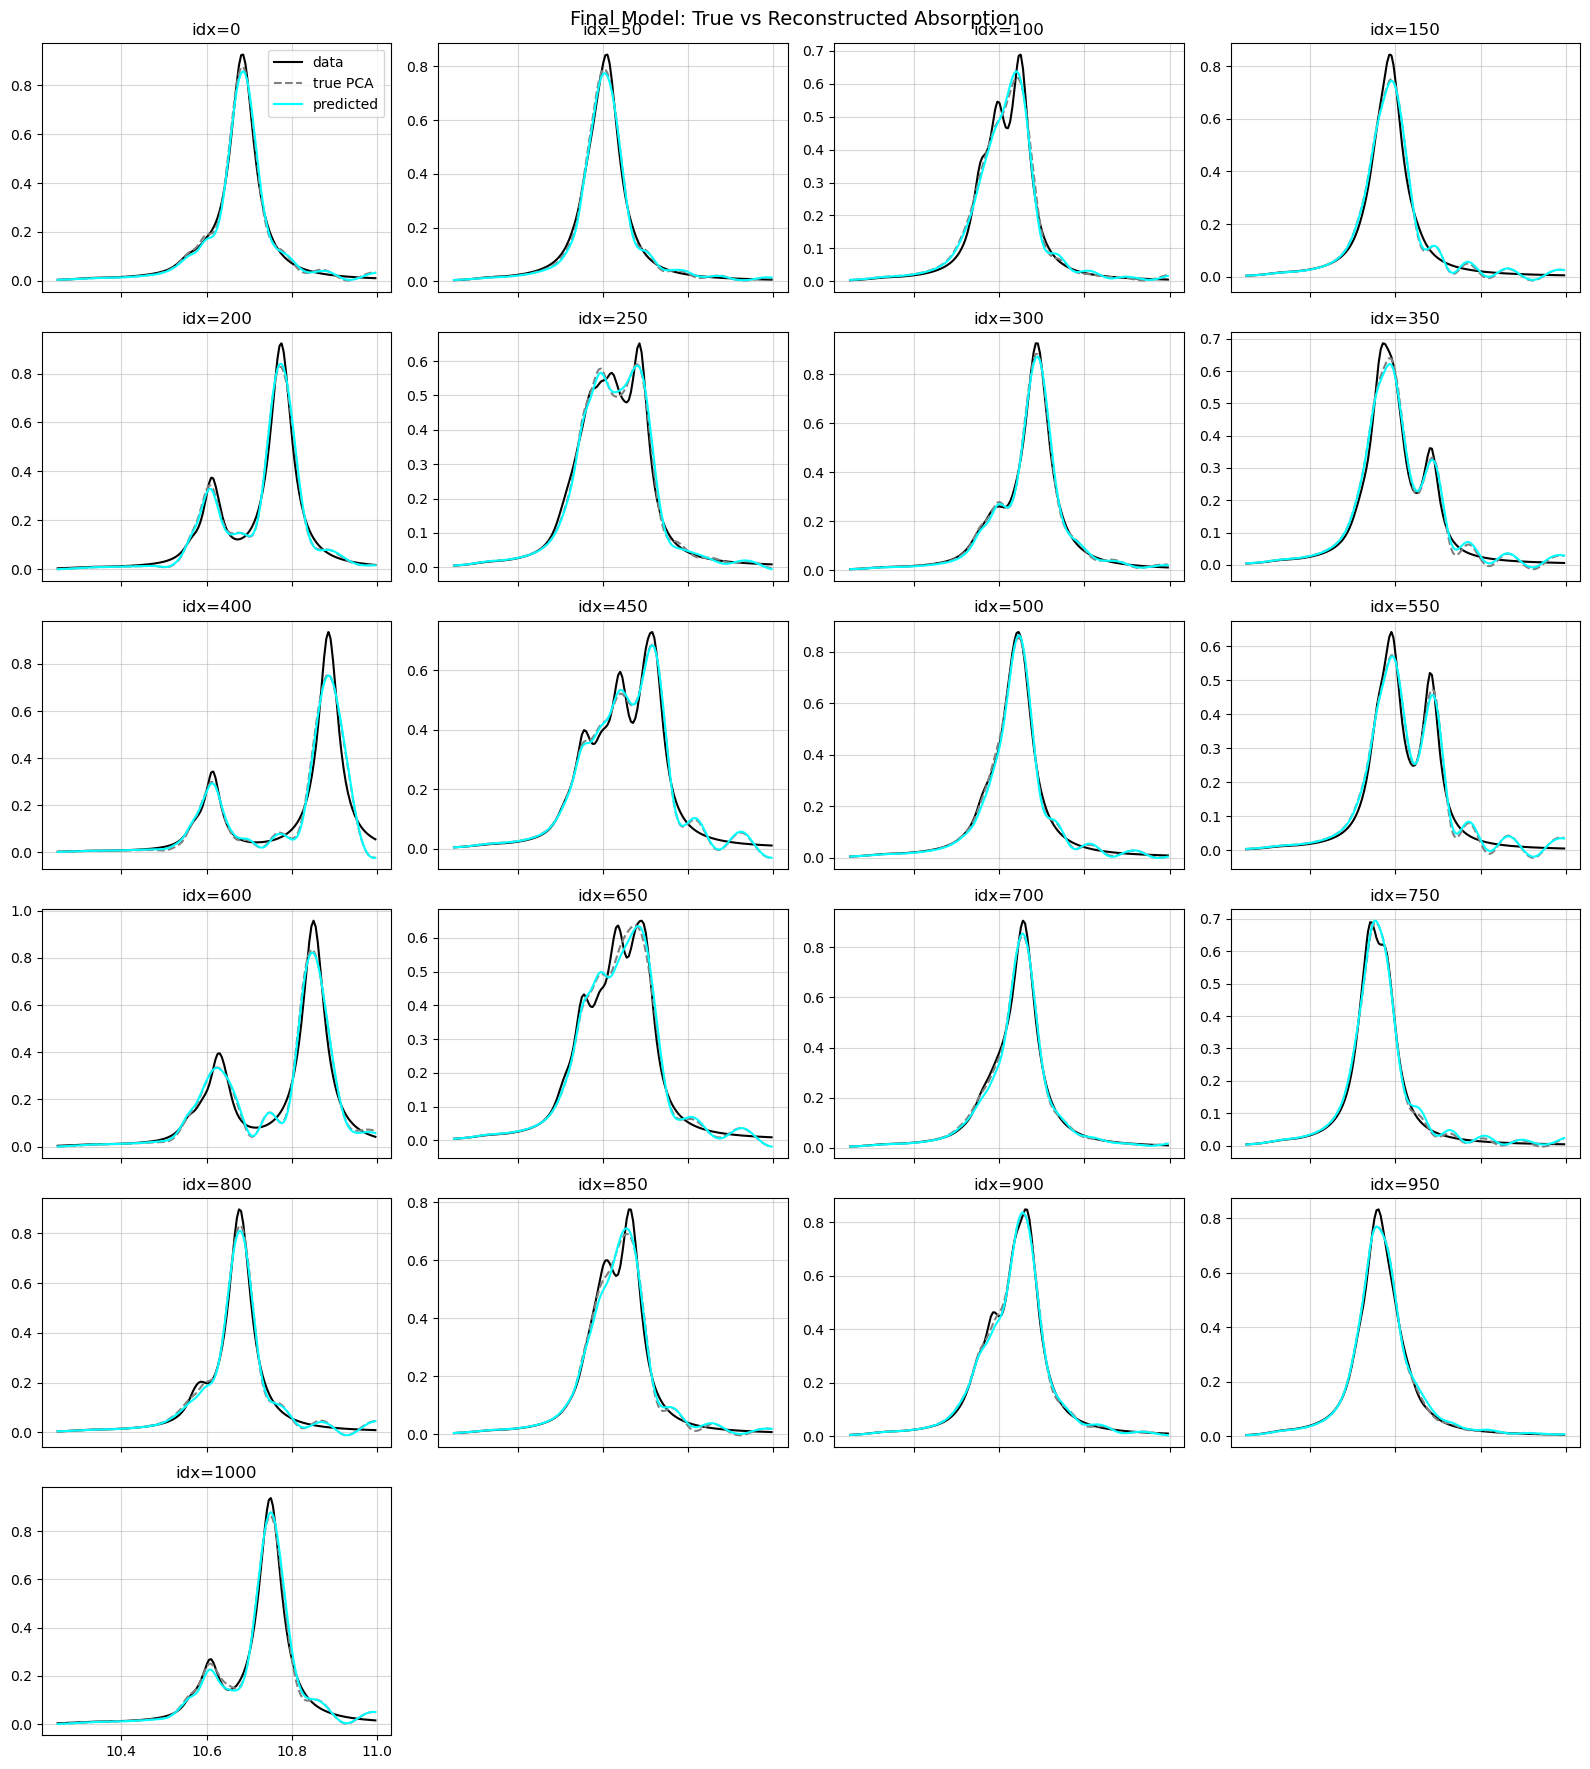

In [14]:
#### PLOT FINAL MODEL RECONSTRUCTIONS ####
final_model_net.eval()
with torch.no_grad():
    geom_sel = data.geom[TEST_IDX]
    feat_sel = data.feat[TEST_IDX]
    pred_sel = final_model_net(geom_sel)
    pred_spec_sel = data.reconstruct_spectrum(pred_sel).numpy()
    true_spec_sel = data.reconstruct_spectrum(feat_sel).numpy()
    raw_spec_sel = _raw_abs[TEST_IDX]

wl_plot = np.asarray(data.wl)
n_plot = len(TEST_IDX)
ncols = 4
nrows = (n_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(TEST_IDX):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_sel[i], color='cyan', label='predicted')
    ax.set_title(f"idx={int(idx)}")
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle("Final Model: True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
plt.show()

#### <span style="color:cyan">**Training - Final Model (ensemble)**</span>

In [15]:
#### ENSEMBLE (FOLD MODELS) ####
# Load all fold checkpoints and average their coefficient predictions.
# reconstruct_spectrum is linear so averaging coeffs = averaging spectra.
n_folds = loader_config['splits']
fold_models = []
for i in range(n_folds):
    ckpt = torch.load(
        f'{train_config["path"]}/fold{i}/best_pca_reg.pt',
        weights_only=False
    )
    m = PcaMLP(
        MLP_config['k'],
        MLP_config['hidden_dim'],
        MLP_config['n_layers'],
        MLP_config['p'],
        input_dim=MLP_config['input_dim']
    )
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    fold_models.append(m)

# Evaluate ensemble on test set
ens_coeff_sum = 0.0
ens_recon_sum = 0.0
ens_samples = 0
ens_peak_abs_errs = []
ens_peak_loc_errs = []
_mse = torch.nn.MSELoss()

with torch.no_grad():
    for geom, feat in test_loader:
        ensemble_coeffs = torch.stack([m(geom) for m in fold_models]).mean(dim=0)
        pred_spec = data.reconstruct_spectrum(ensemble_coeffs)
        true_spec = data.reconstruct_spectrum(feat)

        batch_n = geom.shape[0]
        ens_coeff_sum += _mse(ensemble_coeffs, feat).item() * batch_n
        ens_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        ens_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        ens_peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        ens_peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

ens_coeff_mse = ens_coeff_sum / max(ens_samples, 1)
ens_recon_mse = ens_recon_sum / max(ens_samples, 1)
ens_peak_mae  = torch.cat(ens_peak_abs_errs).mean().item()
ens_peak_loc  = torch.cat(ens_peak_loc_errs).mean().item()

ensemble_metrics = {
    "test_coeff_mse":      float(ens_coeff_mse),
    "test_recon_mse":      float(ens_recon_mse),
    "test_recon_rmse":     float(math.sqrt(ens_recon_mse)),
    "peak_mae":            float(ens_peak_mae),
    "peak_loc_error_um":   float(ens_peak_loc),
    "n_models":            n_folds,
    "n_test":              int(ens_samples),
}

em_w = max(len(k) for k in ensemble_metrics) + 2
print(f"\n{'='*72}")
print(f"Ensemble ({n_folds} fold models, evaluated once on test)")
print(f"{'='*72}")
for k, v in ensemble_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{em_w}} {fmt}")
print("=" * 72)

# Save ensemble metrics alongside the rest
kfold_results['ensemble'] = ensemble_metrics
with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


Ensemble (4 fold models, evaluated once on test)
test_coeff_mse        0.00745863
test_recon_mse       9.93159e-05
test_recon_rmse       0.00996574
peak_mae              0.00784466
peak_loc_error_um     0.00160363
n_models                       4
n_test                       153


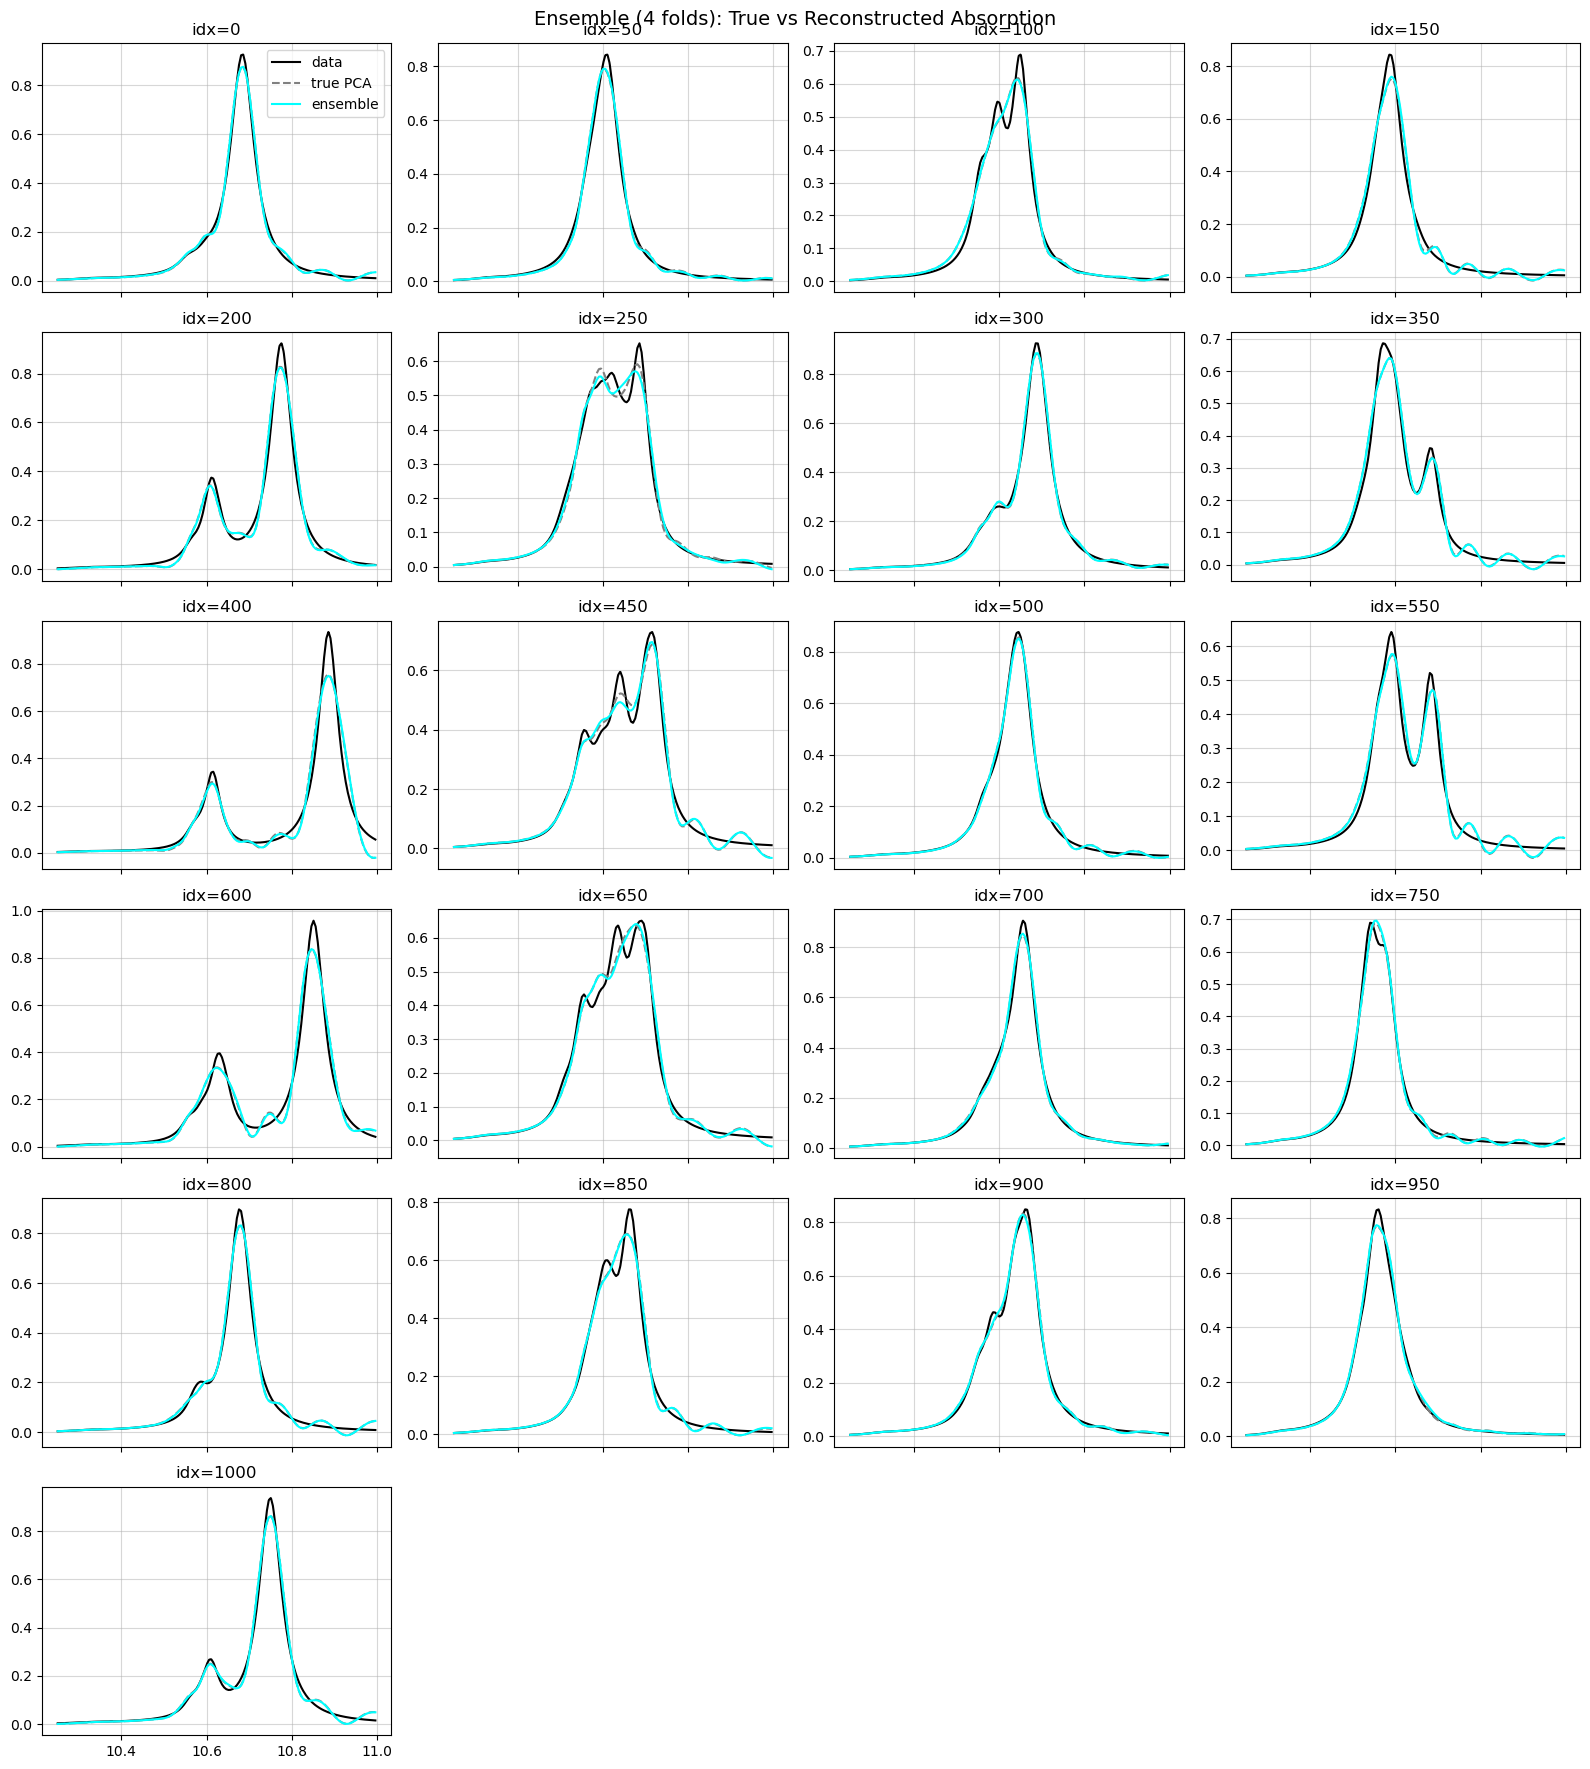

In [16]:
#### PLOT ENSEMBLE RECONSTRUCTIONS ####
with torch.no_grad():
    geom_sel = data.geom[TEST_IDX]
    feat_sel = data.feat[TEST_IDX]
    ens_coeffs_sel = torch.stack([m(geom_sel) for m in fold_models]).mean(dim=0)
    ens_spec_sel = data.reconstruct_spectrum(ens_coeffs_sel).numpy()

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(TEST_IDX):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, ens_spec_sel[i], color='cyan', label='ensemble')
    ax.set_title(f"idx={int(idx)}")
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f"Ensemble ({n_folds} folds): True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
plt.show()